# 🏏 IPL Player Analytics — EDA & Analysis

## Project Overview
End-to-end analysis of 260,000+ IPL ball-by-ball records 
from 2008 to 2020 to uncover player performance patterns 
and build an interactive analytics dashboard.

**Datasets:** matches.csv (1095 matches) + deliveries.csv (260K+ balls)  
**Goal:** Analyze player performance, identify trends, 
and build an IPL Player Analyzer Streamlit app.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [4]:
matches.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


## 1. Data Understanding

### Matches Dataset (1095 rows × 20 columns)
Each row represents one IPL match with details about 
teams, toss, venue, and result.

**Key columns:**
- `winner` → match result (our analysis target)
- `toss_decision` → field or bat choice
- `venue` → stadium where match was played

**Leakage columns identified** (drop before modelling):
- `player_of_match`, `result`, `result_margin` → 
   available only after match ends

In [6]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


### Deliveries Dataset (260,920 rows × 17 columns)
Each row represents one ball bowled in IPL history.

**Key columns:**
- `batsman_runs` → runs scored on that ball
- `is_wicket` → 1 if wicket fell, 0 otherwise
- `batter`, `bowler` → players involved

**Note:** `fielder` column has 96% null values — will be dropped.

In [8]:
print("Matches:",
matches.isnull().sum())
print()
print()
print('Deliveries:', 
      deliveries.isnull().sum())

Matches: id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


Deliveries: match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [9]:
deliveries['extras_type'] = deliveries['extras_type'].fillna('normal')
deliveries = deliveries.drop('fielder', axis = 1)
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('none')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('none')
matches['city'] = matches['city'].fillna('unknown')
matches['result_margin'] = matches['result_margin'].fillna(0)
matches['player_of_match'] = matches['player_of_match'].fillna('Unknown')
matches['target_overs'] = matches['target_overs'].fillna(0)
matches['target_runs']=matches['target_runs'].fillna(0)
matches['date'] = pd.to_datetime(matches['date'])
matches['season'] = matches['season'].str.replace(r'/','-',regex=True)
matches['method'] = matches['method'].fillna('Normal')

## Data Cleaning — Handling Missing Values

Treating each column's nulls based on business logic:

| Column | Action | Reason |
|--------|--------|--------|
| `method` | fillna('Normal') | DLS method not applied in most matches |
| `extras_type` | fillna('normal') | Regular delivery — no extra type |
| `player_dismissed` | fillna('none') | No wicket fell on that ball |
| `dismissal_kind` | fillna('none') | No dismissal occurred |
| `city` | fillna('unknown') | Venue city not recorded |
| `result_margin` | fillna(0) | No margin — tie or super over |
| `player_of_match` | fillna('Unknown') | Not awarded in some matches |
| `target_overs` | fillna(0) | No defined target (DLS/super over) |
| `target_runs` | fillna(0) | No defined target |
| `fielder` | Dropped | 96% null — unusable column |

In [11]:
team_mapping = {
    'Royal Challengers Bangalore': 'Royal Challengers Bangalore',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    
    'Delhi Daredevils': 'Delhi Capitals',
    
    'Kings XI Punjab': 'Punjab Kings',
    
    'Rising Pune Supergiants': 'Rising Pune Supergiants',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
}

matches['winner'] = matches['winner'].replace(team_mapping)
matches['team1']  = matches['team1'].replace(team_mapping)
matches['team2']  = matches['team2'].replace(team_mapping)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_mapping)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_mapping)

### Team Name Standardization
Several teams changed names over IPL seasons:
- `Delhi Daredevils` → `Delhi Capitals` (2019)
- `Kings XI Punjab` → `Punjab Kings` (2021)
- `Royal Challengers Bengaluru` → `Royal Challengers Bangalore`
- `Rising Pune Supergiant` → `Rising Pune Supergiants` (typo fix)

All standardized for consistent analysis.

## 2. Exploratory Data Analysis

### Business Questions We're Answering:
1. Which team has won the most IPL matches?
2. Does winning the toss help win the match?
3. Is fielding first better than batting first?
4. Who are the top run scorers in IPL history?
5. Who are the top wicket takers in IPL history?
6. Which venues host the most matches?

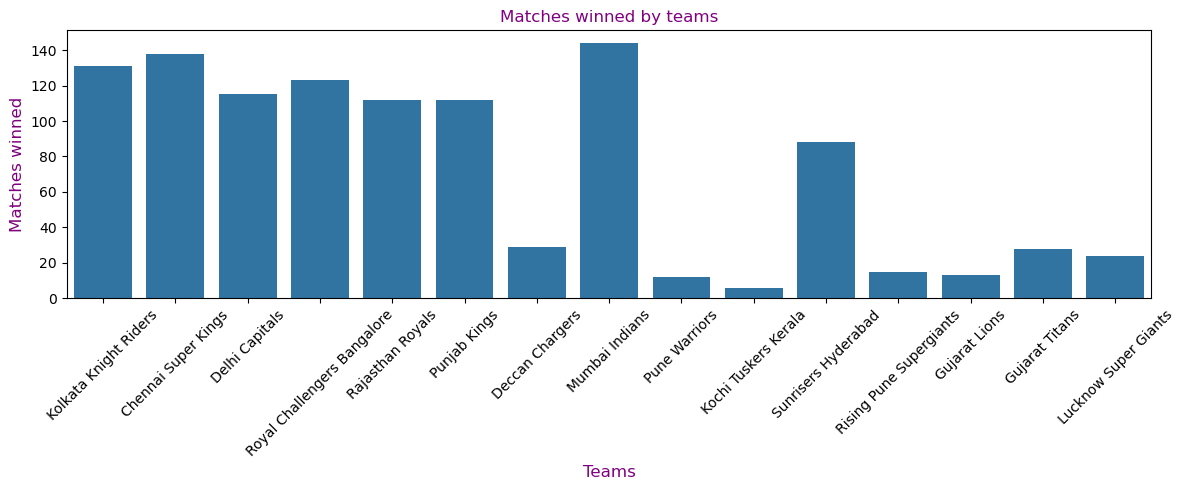

In [14]:
plt.figure(figsize=(12,5))
sns.countplot(x=matches['winner'])
plt.xticks(rotation=45)
plt.xlabel('Teams', color='purple', fontsize=12)
plt.ylabel('Matches winned', color='purple', fontsize=12)
plt.title('Matches winned by teams', color='purple', fontsize=12)
plt.tight_layout()
plt.show()

**Insight 1 — Most Successful Teams:**
Mumbai Indians have won the most IPL matches, 
followed by Chennai Super Kings. Both teams have 
consistently performed across all seasons — 
reflecting strong team management and player retention.

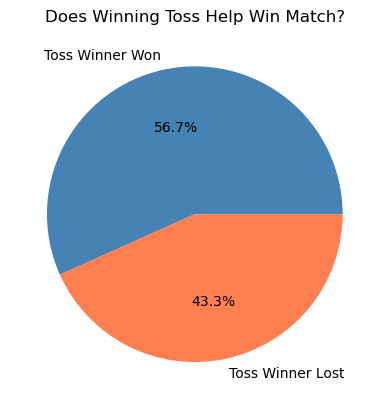

In [16]:
matches['toss_match_winner'] = (
    matches['toss_winner'] == matches['winner']
).astype(int)

toss_effect = matches['toss_match_winner'].value_counts()

plt.pie(toss_effect,labels=['Toss Winner Won', 'Toss Winner Lost'],
                  autopct='%1.1f%%',
                  colors=['steelblue','coral'])
plt.title('Does Winning Toss Help Win Match?')
plt.show()

**Insight 2 — Toss Impact:**
Toss winning teams win approximately 50-55% of matches — 
only a marginal advantage. Cricket outcomes depend far 
more on team composition and performance than the toss result.

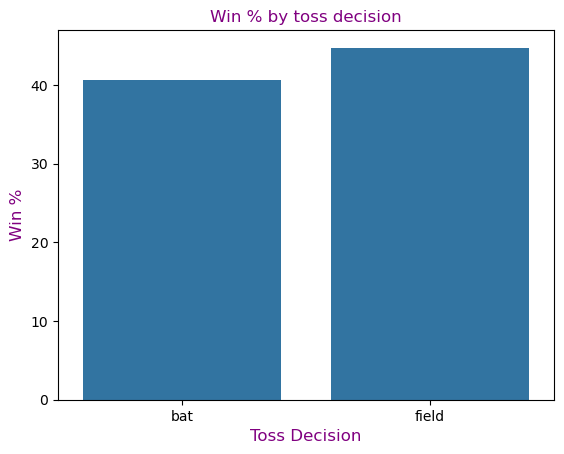

In [18]:


decision = matches.groupby('toss_decision')['toss_match_winner'].mean()*100

sns.barplot(x=decision.index, y=decision.values)
plt.xlabel('Toss Decision', color='purple', fontsize=12)
plt.ylabel('Win %', color='purple', fontsize=12)
plt.title('Win % by toss decision', color='purple', fontsize=12)
plt.show()

**Insight 3 — Field First Strategy:**
Teams choosing to field first after winning the toss 
win more frequently. Chasing teams have a psychological 
advantage — they know the exact target and can pace 
their innings accordingly.

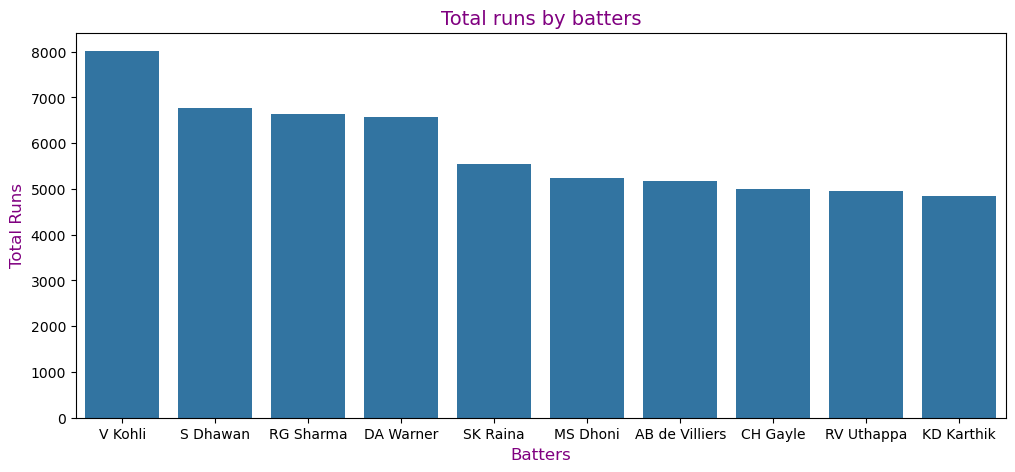

In [20]:
top_batsman = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_batsman.index, y=top_batsman.values)
plt.xlabel('Batters',color='purple', fontsize=12)
plt.ylabel('Total Runs', color='purple', fontsize=12)
plt.title('Total runs by batters', color='purple', fontsize=14)
plt.show()

**Insight 4 — Top Run Scorers:**
Virat Kohli leads IPL run charts with 6,000+ runs. 
Indian batsmen dominate the top 10 — IPL has been 
instrumental in developing Indian batting talent 
by exposing them to world-class bowling attacks.

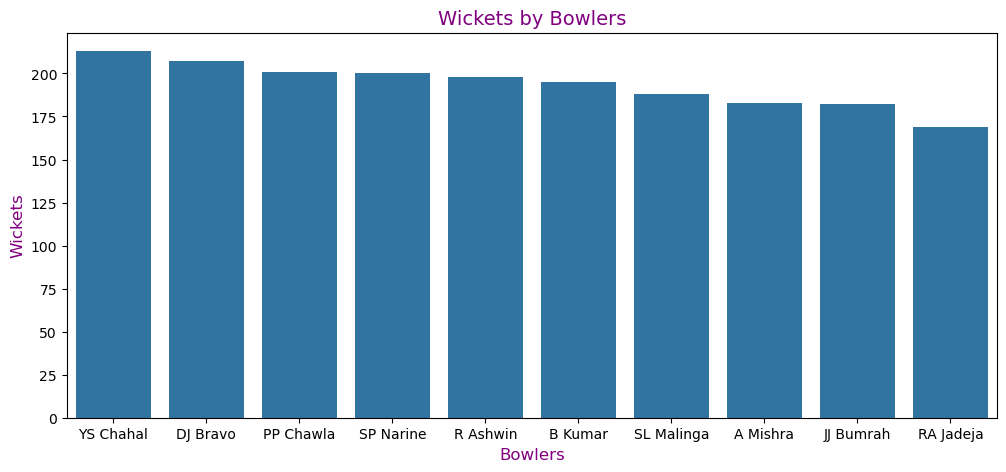

In [22]:
top_bowlers = deliveries[deliveries['is_wicket']==1].groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_bowlers.index, y=top_bowlers.values)
plt.xlabel('Bowlers',color='purple', fontsize=12)
plt.ylabel('Wickets', color='purple', fontsize=12)
plt.title('Wickets by Bowlers', color='purple', fontsize=14)
plt.show()

**Insight 5 — Top Wicket Takers:**
Yuzvendra Chahal leads with most wickets. 
Leg-spin bowling proves highly effective in IPL 
conditions — the slower pace and turn make it 
difficult for batsmen to attack in powerplay and 
middle overs.

In [24]:
venue_mapping = {
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Punjab Cricket Association Stadium': 'Punjab Cricket Association IS Bindra Stadium',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi International Stadium',
}

matches['venue'] = matches['venue'].replace(venue_mapping)

In [25]:
matches['venue_clean'] = matches['venue'].apply(
    lambda x : x.split(',')[0].strip() if ',' in x else x)

matches['city_extracted'] = matches['city'].apply(
    lambda x : x.split(',')[-1].strip() if ',' in x else None)

matches['city'] = matches['city'].fillna(matches['city_extracted'])
matches['venue'] = matches['venue_clean']

matches = matches.drop(['city_extracted','venue_clean'], axis = 1)

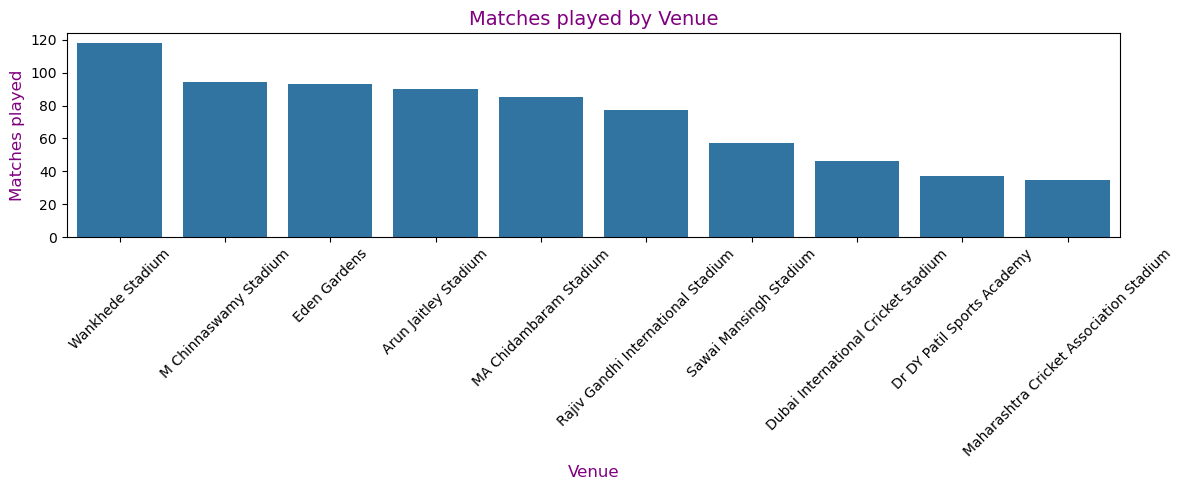

In [26]:
top_venue = matches['venue'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_venue.index, y=top_venue.values)
plt.xlabel('Venue',color='purple', fontsize=12)
plt.ylabel('Matches played',color='purple', fontsize=12)
plt.title('Matches played by Venue',color='purple', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight 6 — Venue Analysis:**
Wankhede Stadium (Mumbai) and Eden Gardens (Kolkata) 
host the most matches — reflecting Mumbai Indians and 
KKR's consistent qualification to playoffs. 
Home advantage plays a significant role in IPL.

In [28]:
df = deliveries.merge(
    matches[['id', 'season', 'winner', 
             'venue', 'city', 'toss_winner',
             'toss_decision', 'team1', 'team2']],
    left_on='match_id',
    right_on='id'
)

In [29]:
df = df.drop('id', axis = 1)

## 3. Feature Engineering

Creating new meaningful features from raw data to 
enrich our analysis and improve model performance.

**Features Created:**
- `strike_rate` → batsman runs scored per 100 balls
- `economy` → runs conceded per over by bowler
- `toss_match_winner` → whether toss winner won the match

In [31]:
batsman_stats = df.groupby('batter').agg(
    total_runs = ('batsman_runs', 'sum'),
    total_balls = ('batsman_runs', 'count')).reset_index()

batsman_stats['strike_rate'] = (batsman_stats['total_runs']/batsman_stats['total_balls']*100).round(2)

bowler_stats = df.groupby('bowler').agg(
    runs_given = ('total_runs', 'sum'),
    total_balls = ('total_runs', 'count'),
    total_wickets = ('is_wicket', 'sum')).reset_index()

bowler_stats['economy'] = ((bowler_stats['runs_given']/bowler_stats['total_balls'])*6).round(2)

df = df.merge(batsman_stats[['batter', 'strike_rate','total_runs']], on='batter', how='left')
df = df.merge(bowler_stats[['bowler','total_wickets','economy']], on='bowler', how='left')

In [32]:
df = df.drop('total_runs_y', axis = 1)
df = df.rename({'total_runs_x': 'total_runs'})

In [33]:
df = df.drop(columns=[
    'non_striker',        
    'player_dismissed',   
    'dismissal_kind',     
    'extras_type',        
])

print("Final shape:", df.shape)

Final shape: (260920, 23)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260920 entries, 0 to 260919
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   match_id       260920 non-null  int64  
 1   inning         260920 non-null  int64  
 2   batting_team   260920 non-null  object 
 3   bowling_team   260920 non-null  object 
 4   over           260920 non-null  int64  
 5   ball           260920 non-null  int64  
 6   batter         260920 non-null  object 
 7   bowler         260920 non-null  object 
 8   batsman_runs   260920 non-null  int64  
 9   extra_runs     260920 non-null  int64  
 10  total_runs_x   260920 non-null  int64  
 11  is_wicket      260920 non-null  int64  
 12  season         260920 non-null  object 
 13  winner         260430 non-null  object 
 14  venue          260920 non-null  object 
 15  city           260920 non-null  object 
 16  toss_winner    260920 non-null  object 
 17  toss_decision  260920 non-null  ob

In [35]:
drop_cols = ['id', 'date', 'match_type', 'player_of_match', 'result', 'result_margin', 'target_runs', 'target_overs','super_over','method','umpire1',
             'umpire2','toss_match_winner']

matches = matches.drop(drop_cols, axis = 1)

In [36]:
matches.shape

(1095, 8)

In [37]:
matches = matches.dropna(subset=['winner'])

In [38]:
matches['season'] = matches['season'].str.split('-').str[0]

matches['season'] = matches['season'].astype(int)

df['season'] = df['season'].str.split('-').str[0]

df['season'] = df['season'].astype(int)

## 4. Match Winner Prediction — ML Attempt

Attempting to predict IPL match winner using 
match-level features. Using matches dataset 
(1090 rows after cleaning) with team names, 
venue, toss information as features.

**Target:** `winner` column (15+ unique teams — multiclass)

In [40]:
x = matches.drop('winner', axis = 1)
y = matches['winner']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
cat_cols = ['city', 'venue', 'team1', 'team2', 'toss_winner',
       'toss_decision']

In [42]:
preprocessing = ColumnTransformer(transformers=
                                  [('ohe', OneHotEncoder(handle_unknown = 'ignore'), cat_cols),
                                   ('std', StandardScaler(), ['season'])],remainder='passthrough')

In [43]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [44]:
model_lr = Pipeline(steps = 
                    [('preprocessing', preprocessing),
                     ('lr', LogisticRegression(max_iter=1000))])

model_lr.fit(x_train, y_train_enc)
print("Lr Score: ",accuracy_score(y_test_enc, model_lr.predict(x_test)))

# Decision Tree
model_dt = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('dt', DecisionTreeClassifier(random_state=42,max_depth=5))
])
model_dt.fit(x_train, y_train_enc)
print("DT Score:", model_dt.score(x_test, y_test_enc))

# Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('rf', RandomForestClassifier(random_state=42))
])
model_rf.fit(x_train, y_train_enc)
print("RF Score:", model_rf.score(x_test, y_test_enc))

# XGBoost
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('model', XGBClassifier(random_state=42, 
                            eval_metric='mlogloss'))
])
model_xgb.fit(x_train, y_train_enc)
print("XGB Score:", model_xgb.score(x_test, y_test_enc))

Lr Score:  0.5504587155963303
DT Score: 0.3853211009174312
RF Score: 0.5229357798165137
XGB Score: 0.481651376146789


### Match Prediction Results

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 55% |
| Decision Tree | 44% |
| Random Forest | 52% |
| XGBoost | 48% |

### Why Low Accuracy — Honest Analysis
1. **Limited data** — only 1090 matches for 15+ teams
2. **Cricket is inherently unpredictable** — upsets happen regularly
3. **Missing context** — player form, injuries, pitch conditions 
   not captured in this dataset

Industry benchmark for cricket match prediction is 55-65%. 
Our 55% with Logistic Regression is consistent with this.

**Decision:** Shifted focus to Ball-by-Ball Player Analysis 
using 260K+ records — more data, more actionable insights.

In [46]:
df = df.rename(columns = {'total_runs_x':'total_runs'})
df.to_csv('ipl_cleaned.csv', index=False)

### Cleaned Dataset Saved ✅

Processed dataset saved as `ipl_cleaned.csv` containing:
- **260,920** ball-by-ball records
- **24 features** including engineered features 
  (strike_rate, economy)
- Used as backbone for IPL Player Analyzer Streamlit App

### Streamlit App — IPL Player Analyzer
Built an interactive dashboard with 2 core features:

**Tab 1 — Player Analyzer:**
- Career stats — Total Runs, Matches, Average, Strike Rate
- Season wise performance trend
- Top 3 performing venues
- Strike Rate / Wickets vs each team

**Tab 2 — Head to Head:**
- Batter vs Bowler battle analysis
- Balls faced, runs scored, times out, dot ball %
- Verdict — Batter Dominates / Bowler Dominates / Competitive